<a href="https://colab.research.google.com/github/SajjitMalla01/Workshop-ai-/blob/main/Text_classification_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Book Review Rating Classification
### Herald College Kathmandu — 6CS012 Machine Learning
**Models:** SimpleRNN · BiLSTM · BiLSTM + GloVe Embeddings

## 1. Setup & Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print('TensorFlow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load & Explore Dataset

In [3]:
FILE_PATH = '/content/drive/MyDrive/Book_review.csv'

df = pd.read_csv(FILE_PATH)

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nMissing Values:')
print(df.isnull().sum())
print('\nSample rows:')
df.head()

Shape: (12000, 4)

Columns: ['Unnamed: 0', 'rating', 'reviewText', 'summary']

Missing Values:
Unnamed: 0    0
rating        0
reviewText    0
summary       2
dtype: int64

Sample rows:


,Unnamed: 0,rating,reviewText,summary
0,0,5,This book was the very first bookmobile book I...,50 + years ago...
1,1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!
2,2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!
3,3,5,I don't normally buy 'mystery' novels because ...,Very good read.
4,4,5,"This isn't the kind of book I normally read, a...",Great Story!


In [4]:
# Keep only relevant columns
df = df[['reviewText', 'rating']].copy()
df.columns = ['review', 'rating']

# Drop nulls
df.dropna(inplace=True)
print('Shape after removing nulls:', df.shape)

# Rating distribution
print('\nRating distribution:')
print(df['rating'].value_counts().sort_index())

Shape after removing nulls: (12000, 2)

Rating distribution:
rating
1    2000
2    2000
3    2000
4    3000
5    3000
Name: count, dtype: int64


/tmp/ipykernel_1459/1133363370.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['rating'], palette='Blues_d')


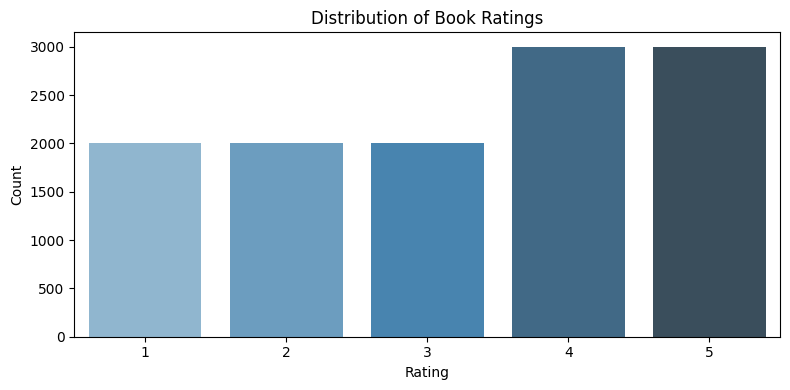

In [5]:
# Rating distribution plot
plt.figure(figsize=(8, 4))
sns.countplot(x=df['rating'], palette='Blues_d')
plt.title('Distribution of Book Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Text Preprocessing

In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'\d+', '', text)               # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = text.strip()
    words = text.split()
    cleaned = [
        lemmatizer.lemmatize(w)
        for w in words
        if w not in stop_words
    ]
    return ' '.join(cleaned)

print('Cleaning reviews...')
df['clean_review'] = df['review'].astype(str).apply(clean_text)
print('Done.')

df[['review', 'clean_review']].head(3)

Cleaning reviews...
Done.


,review,clean_review
0,This book was the very first bookmobile book I...,book first bookmobile book bought school book ...
1,"When I read the description for this book, I c...",read description book couldnt wait read downlo...
2,I just had to edit this review. This book is a...,edit review book believe got right updated rew...


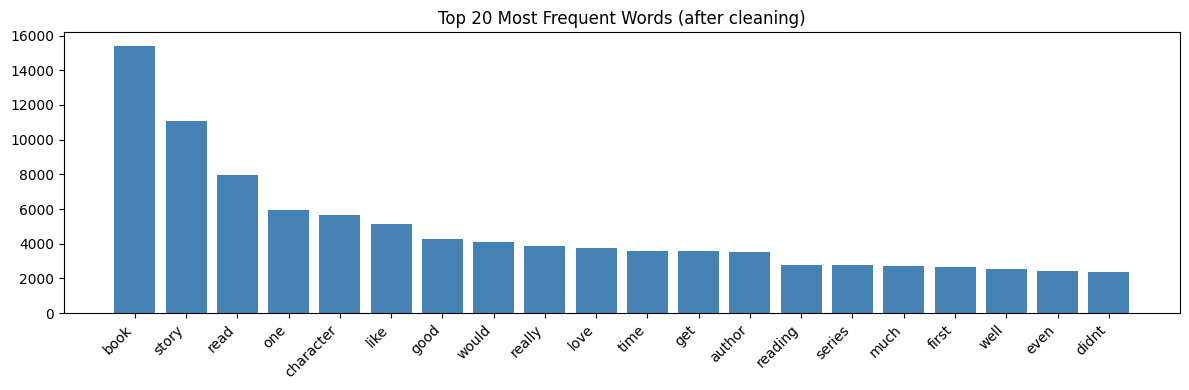

In [7]:
# Top 20 most frequent words
all_words = ' '.join(df['clean_review']).split()
word_freq = Counter(all_words)
common_words = word_freq.most_common(20)

words  = [w for w, _ in common_words]
counts = [c for _, c in common_words]

plt.figure(figsize=(12, 4))
plt.bar(words, counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Frequent Words (after cleaning)')
plt.tight_layout()
plt.show()

## 4. Train / Validation / Test Split
**Strategy:** 70% train · 15% validation · 15% test (stratified)

In [8]:
X = df['clean_review']
y = df['rating']

# Step 1: split off 30% → (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Step 2: split temp 50/50 → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Training   : {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)')
print(f'Validation : {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test       : {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)')

Training   : 8,400 samples (70.0%)
Validation : 1,800 samples (15.0%)
Test       : 1,800 samples (15.0%)


## 5. Tokenisation & Padding
A single tokenizer is fitted on the training set and reused for all three models.

In [37]:
MAX_WORDS = 15000

# Fit tokenizer on TRAINING data only
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Sequence lengths to determine max_len
train_seqs_raw = tokenizer.texts_to_sequences(X_train)
seq_lengths = [len(s) for s in train_seqs_raw]
MAX_LEN = int(np.percentile(seq_lengths, 75))  # changed from 95 → 75

print(f'Vocabulary size   : {MAX_WORDS:,}')
print(f'Max sequence len  : {MAX_LEN} (75th percentile)')

def encode(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post')

X_train_pad = encode(X_train)
X_val_pad   = encode(X_val)
X_test_pad  = encode(X_test)

# One-hot labels (ratings 1-5  →  classes 0-4)
y_train_cat = to_categorical(y_train - 1, num_classes=5)
y_val_cat   = to_categorical(y_val   - 1, num_classes=5)
y_test_cat  = to_categorical(y_test  - 1, num_classes=5)

print('\nPadded shapes:')
print(f'  Train : {X_train_pad.shape}')
print(f'  Val   : {X_val_pad.shape}')
print(f'  Test  : {X_test_pad.shape}')

Vocabulary size   : 15,000
Max sequence len  : 66 (75th percentile)

Padded shapes:
  Train : (8400, 66)
  Val   : (1800, 66)
  Test  : (1800, 66)


## 6. Shared Callback

In [85]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,          # was 3 — give models more time
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,          # was 2 — don't cut LR so quickly
    verbose=1
)

EMBEDDING_DIM = 128
BATCH_SIZE    = 64
EPOCHS        = 15       # was 10 — allow more epochs now patience is higher

## 7. Model 1 — SimpleRNN

In [86]:
model_rnn = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, mask_zero=True),
    SimpleRNN(128, return_sequences=True),
    Dropout(0.3),
    SimpleRNN(64),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(5, activation='softmax')
], name='SimpleRNN')

model_rnn.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    metrics=['accuracy']
)
model_rnn.summary()

Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_8 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [87]:
import time
t0 = time.time()

history_rnn = model_rnn.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr]
)

rnn_train_time = time.time() - t0
print(f'Training time: {rnn_train_time:.0f}s')


Epoch 1/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.2480 - loss: 1.6125 - val_accuracy: 0.2828 - val_loss: 1.5604 - learning_rate: 5.0000e-04
Epoch 2/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3925 - loss: 1.3638 - val_accuracy: 0.3706 - val_loss: 1.3703 - learning_rate: 5.0000e-04
Epoch 3/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5414 - loss: 1.0738 - val_accuracy: 0.3828 - val_loss: 1.3869 - learning_rate: 5.0000e-04
Epoch 4/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7313 - loss: 0.7105 - val_accuracy: 0.3511 - val_loss: 1.6561 - learning_rate: 5.0000e-04
Epoch 5/15
128/132 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8733 - loss: 0.3841
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8735 - loss: 0.3749 - val_accuracy: 0.3611 - val_loss: 1.9993 - learning_rate: 5.0000e-04
Epoch 6/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accurac

In [88]:
# Evaluate on TEST set (same X_test_pad used for ALL models)
rnn_pred_probs   = model_rnn.predict(X_test_pad)
rnn_pred_classes = np.argmax(rnn_pred_probs, axis=1) + 1   # back to 1-5

rnn_loss, rnn_acc = model_rnn.evaluate(X_test_pad, y_test_cat, verbose=0)

print(f'RNN Test Accuracy : {rnn_acc:.4f}')
print(f'RNN Test Loss     : {rnn_loss:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, rnn_pred_classes))

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
RNN Test Accuracy : 0.3706
RNN Test Loss     : 1.3602

Classification Report:
              precision    recall  f1-score   support

           1       0.39      0.53      0.45       300
           2       0.28      0.18      0.22       300
           3       0.19      0.12      0.15       300
           4       0.33      0.27      0.30       450
           5       0.46      0.66      0.54       450

    accuracy                           0.37      1800
   macro avg       0.33      0.35      0.33      1800
weighted avg       0.34      0.37      0.35      1800



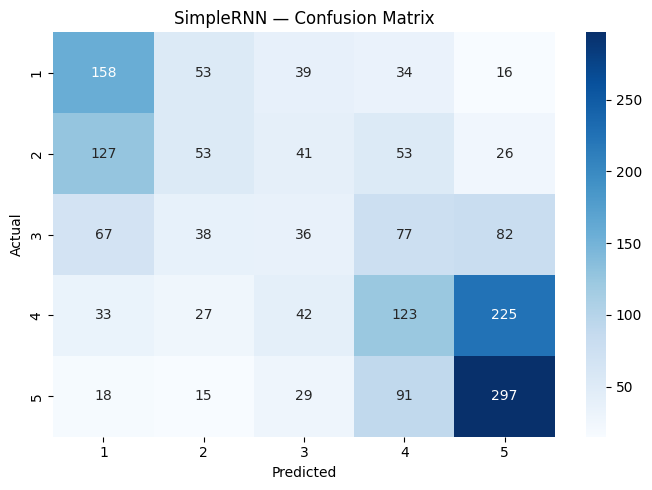

In [89]:
# Confusion Matrix
cm_rnn = confusion_matrix(y_test, rnn_pred_classes)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1,6), yticklabels=range(1,6))
plt.title('SimpleRNN — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

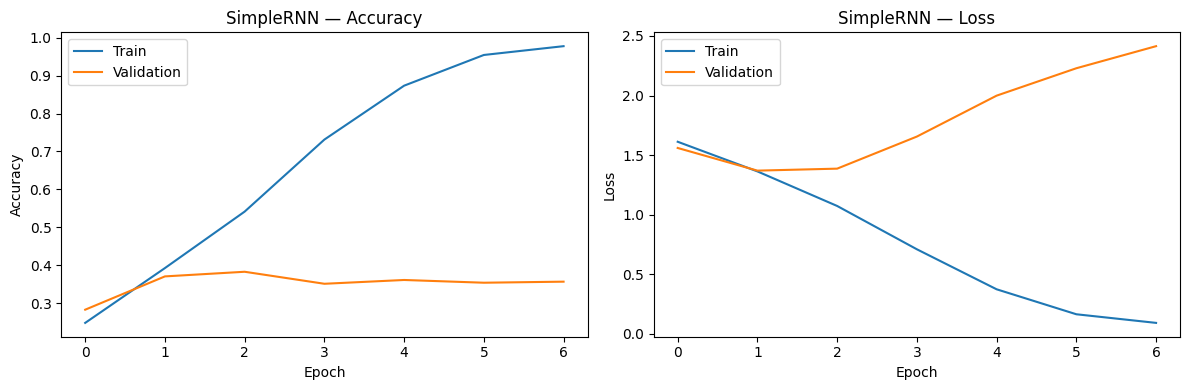

In [90]:
# SimpleRNN — Learning Curves
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(history_rnn.history['accuracy'], label='Train')
plt.plot(history_rnn.history['val_accuracy'], label='Validation')
plt.title('SimpleRNN — Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_rnn.history['loss'], label='Train')
plt.plot(history_rnn.history['val_loss'], label='Validation')
plt.title('SimpleRNN — Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.show()


## 8. Model 2 — Bidirectional LSTM

In [91]:
model_lstm = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax')
], name='BiLSTM')

model_lstm.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_lstm.summary()

Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_15 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [92]:
t0 = time.time()

history_lstm = model_lstm.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr]
)

lstm_train_time = time.time() - t0
print(f'Training time: {lstm_train_time:.0f}s')


Epoch 1/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3193 - loss: 1.4787 - val_accuracy: 0.4228 - val_loss: 1.2916 - learning_rate: 0.0010
Epoch 2/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4539 - loss: 1.1800 - val_accuracy: 0.4489 - val_loss: 1.2407 - learning_rate: 0.0010
Epoch 3/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5685 - loss: 0.9596 - val_accuracy: 0.4550 - val_loss: 1.2832 - learning_rate: 0.0010
Epoch 4/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6694 - loss: 0.7741 - val_accuracy: 0.4644 - val_loss: 1.4833 - learning_rate: 0.0010
Epoch 5/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7685 - loss: 0.5953
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7596 - loss: 0.6035 - val_accuracy: 0.4550 - val_loss: 1.6691 - learning_rate: 0.0010
Epoch 6/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8480 - loss: 0.4

In [93]:
lstm_pred_probs   = model_lstm.predict(X_test_pad)
lstm_pred_classes = np.argmax(lstm_pred_probs, axis=1) + 1

lstm_loss, lstm_acc = model_lstm.evaluate(X_test_pad, y_test_cat, verbose=0)

print(f'BiLSTM Test Accuracy : {lstm_acc:.4f}')
print(f'BiLSTM Test Loss     : {lstm_loss:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, lstm_pred_classes))

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
BiLSTM Test Accuracy : 0.4378
BiLSTM Test Loss     : 1.2240

Classification Report:
              precision    recall  f1-score   support

           1       0.46      0.64      0.53       300
           2       0.33      0.26      0.29       300
           3       0.31      0.21      0.25       300
           4       0.42      0.39      0.41       450
           5       0.54      0.62      0.58       450

    accuracy                           0.44      1800
   macro avg       0.41      0.42      0.41      1800
weighted avg       0.42      0.44      0.42      1800



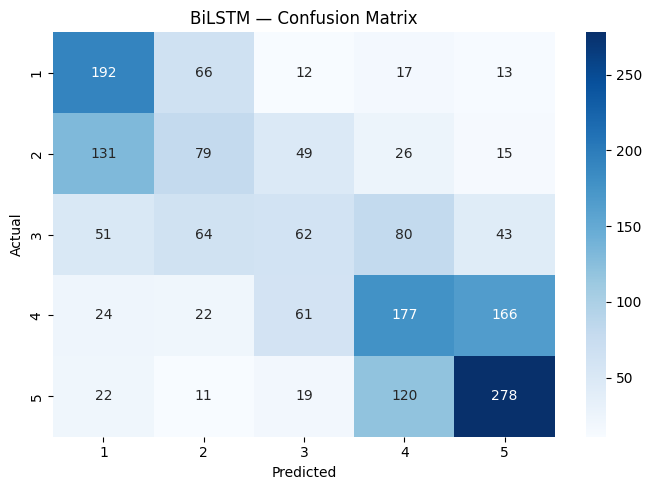

In [94]:
# BiLSTM — Confusion Matrix
cm_lstm = confusion_matrix(y_test, lstm_pred_classes)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1,6), yticklabels=range(1,6))
plt.title('BiLSTM — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


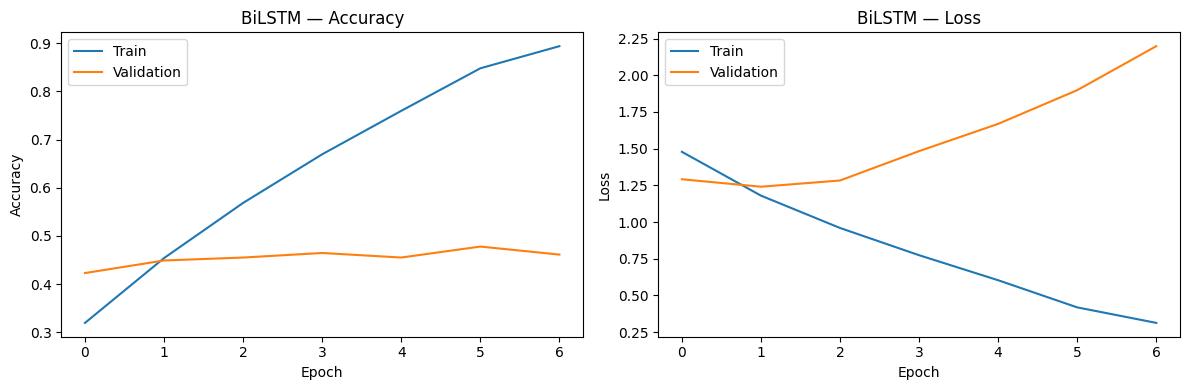

In [95]:
# Learning curves
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(history_lstm.history['accuracy'], label='Train')
plt.plot(history_lstm.history['val_accuracy'], label='Validation')
plt.title('BiLSTM — Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_lstm.history['loss'], label='Train')
plt.plot(history_lstm.history['val_loss'], label='Validation')
plt.title('BiLSTM — Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.show()

## 9. Model 3 — BiLSTM + GloVe Embeddings
Download `glove-wiki-gigaword-50` via gensim, build an embedding matrix from the **training vocabulary**, then use it as fixed (non-trainable) weights.

In [22]:
!pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 70.8 MB/s eta 0:00:00


In [74]:
import gensim.downloader as api

print('Downloading GloVe (glove-wiki-gigaword-50) — ~66 MB, one-time download...')
glove_model = api.load('glove-wiki-gigaword-50')
GLOVE_DIM   = 50
print('GloVe loaded successfully.')

GloVe loaded successfully.


In [96]:
# Build embedding matrix from the SAME tokenizer used for all models
word_index = tokenizer.word_index

embedding_matrix = np.zeros((MAX_WORDS, GLOVE_DIM))
hits, misses = 0, 0

for word, idx in word_index.items():
    if idx >= MAX_WORDS:
        continue
    if word in glove_model:
        embedding_matrix[idx] = glove_model[word]
        hits += 1
    else:
        misses += 1

print(f'GloVe hits  : {hits:,}')
print(f'GloVe misses: {misses:,}')
print(f'Coverage    : {hits/(hits+misses)*100:.1f}%')

GloVe hits  : 13,043
GloVe misses: 1,956
Coverage    : 87.0%


In [98]:
# Reuse the same padded sequences — tokenizer & MAX_LEN are identical
# (Re-encoding would produce byte-for-byte identical arrays; this saves memory)
X_train_pad_g, X_val_pad_g, X_test_pad_g = X_train_pad, X_val_pad, X_test_pad

model_glove = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=GLOVE_DIM,
        weights=[embedding_matrix],
        trainable=False          # freeze GloVe weights
    ),
    Bidirectional(LSTM(64)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
], name='BiLSTM_GloVe')

model_glove.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_glove.summary()

Model: "BiLSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_17 (Embedding)        │ ?                      │       750,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 750,000 (2.86 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 750,000 (2.86 MB)

In [99]:
t0 = time.time()

history_glove = model_glove.fit(
    X_train_pad_g, y_train_cat,
    validation_data=(X_val_pad_g, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr]
)

glove_train_time = time.time() - t0
print(f'Training time: {glove_train_time:.0f}s')


Epoch 1/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.3163 - loss: 1.5157 - val_accuracy: 0.3700 - val_loss: 1.4267 - learning_rate: 0.0010
Epoch 2/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3917 - loss: 1.3917 - val_accuracy: 0.3944 - val_loss: 1.3725 - learning_rate: 0.0010
Epoch 3/15
129/132 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4168 - loss: 1.3560
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4182 - loss: 1.3565 - val_accuracy: 0.3678 - val_loss: 1.4131 - learning_rate: 0.0010
Epoch 4/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4175 - loss: 1.3158 - val_accuracy: 0.4261 - val_loss: 1.3300 - learning_rate: 5.0000e-04
Epoch 5/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4371 - loss: 1.2907 - val_accuracy: 0.4211 - val_loss: 1.3198 - learning_rate: 5.0000e-04
Training time: 13s


## 10. Final Model Comparison

In [100]:
glove_pred_probs   = model_glove.predict(X_test_pad_g)
glove_pred_classes = np.argmax(glove_pred_probs, axis=1) + 1

glove_loss, glove_acc = model_glove.evaluate(X_test_pad_g, y_test_cat, verbose=0)

print(f'BiLSTM+GloVe Test Accuracy : {glove_acc:.4f}')
print(f'BiLSTM+GloVe Test Loss     : {glove_loss:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, glove_pred_classes))

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
BiLSTM+GloVe Test Accuracy : 0.3644
BiLSTM+GloVe Test Loss     : 1.4377

Classification Report:
              precision    recall  f1-score   support

           1       0.34      0.59      0.43       300
           2       0.30      0.19      0.23       300
           3       0.24      0.09      0.13       300
           4       0.34      0.45      0.39       450
           5       0.49      0.44      0.46       450

    accuracy                           0.36      1800
   macro avg       0.34      0.35      0.33      1800
weighted avg       0.35      0.36      0.34      1800



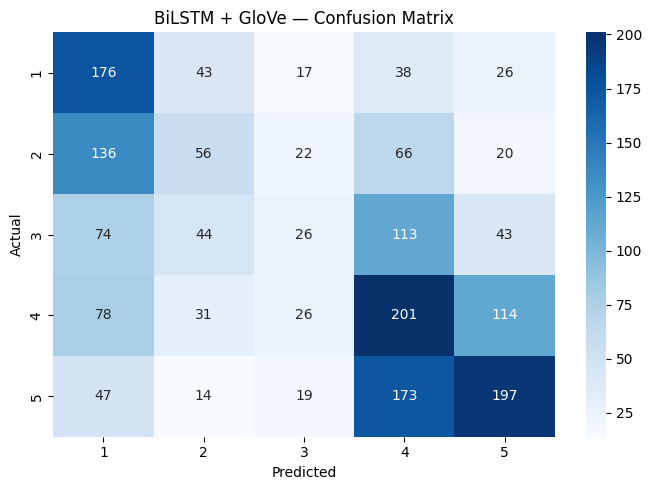

In [101]:
# BiLSTM + GloVe — Confusion Matrix
cm_glove = confusion_matrix(y_test, glove_pred_classes)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_glove, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1,6), yticklabels=range(1,6))
plt.title('BiLSTM + GloVe — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


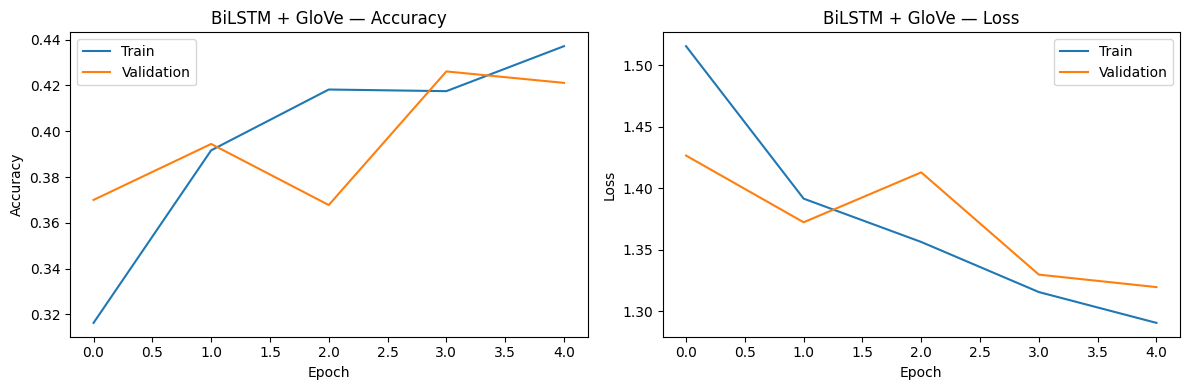

In [102]:
# BiLSTM + GloVe — Learning Curves
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(history_glove.history['accuracy'], label='Train')
plt.plot(history_glove.history['val_accuracy'], label='Validation')
plt.title('BiLSTM + GloVe — Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_glove.history['loss'], label='Train')
plt.plot(history_glove.history['val_loss'], label='Validation')
plt.title('BiLSTM + GloVe — Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.show()


         Model Test Accuracy Test Loss Train Time (s)
     SimpleRNN        0.3706    1.3602             28
        BiLSTM        0.4378    1.2240             17
BiLSTM + GloVe        0.3644    1.4377             13


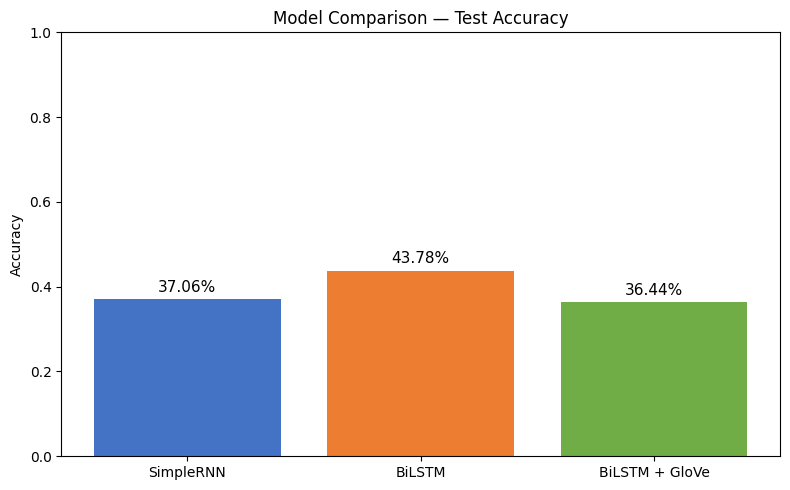

In [103]:
models      = ['SimpleRNN', 'BiLSTM', 'BiLSTM + GloVe']
accuracies  = [rnn_acc, lstm_acc, glove_acc]
losses      = [rnn_loss, lstm_loss, glove_loss]
train_times = [rnn_train_time, lstm_train_time, glove_train_time]

summary_df = pd.DataFrame({
    'Model'         : models,
    'Test Accuracy' : [f'{a:.4f}' for a in accuracies],
    'Test Loss'     : [f'{l:.4f}' for l in losses],
    'Train Time (s)': [f'{t:.0f}' for t in train_times],
})
print(summary_df.to_string(index=False))

# Bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['#4472C4','#ED7D31','#70AD47'])
plt.ylim(0, 1)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.2%}', ha='center', va='bottom', fontsize=11)
plt.title('Model Comparison — Test Accuracy')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

## 11. Inference — Predict a Single Review

In [104]:
def predict_rating(review_text, model=model_glove):
    """Predict the star rating (1-5) for a new review."""
    cleaned   = clean_text(review_text)
    seq       = tokenizer.texts_to_sequences([cleaned])
    padded    = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    probs     = model.predict(padded, verbose=0)
    rating    = np.argmax(probs, axis=1)[0] + 1
    confidence = probs[0][rating - 1]
    print(f'Predicted Rating : {rating} / 5   (confidence: {confidence:.1%})')
    return rating

predict_rating('This book was absolutely amazing and very informative!')
predict_rating('Terrible book, total waste of money. Very disappointed.')

Predicted Rating : 5 / 5   (confidence: 29.9%)
Predicted Rating : 1 / 5   (confidence: 48.8%)


np.int64(1)

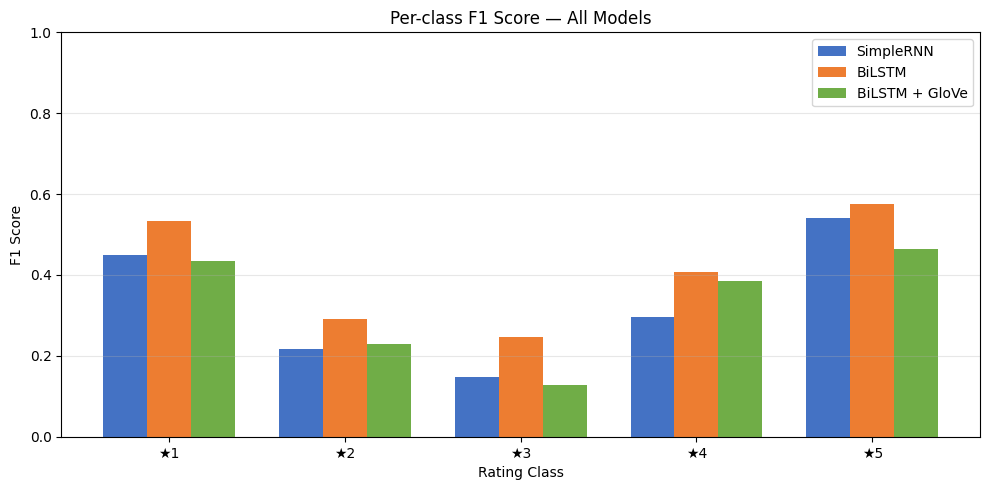

In [105]:
# Per-class F1 bar chart — all 3 models side by side
from sklearn.metrics import f1_score
import numpy as np

classes = [1, 2, 3, 4, 5]
f1_rnn   = f1_score(y_test, rnn_pred_classes,   average=None, labels=classes)
f1_lstm  = f1_score(y_test, lstm_pred_classes,  average=None, labels=classes)
f1_glove = f1_score(y_test, glove_pred_classes, average=None, labels=classes)

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, f1_rnn,   width, label='SimpleRNN',     color='#4472C4')
ax.bar(x,         f1_lstm,  width, label='BiLSTM',        color='#ED7D31')
ax.bar(x + width, f1_glove, width, label='BiLSTM + GloVe',color='#70AD47')

ax.set_xlabel('Rating Class')
ax.set_ylabel('F1 Score')
ax.set_title('Per-class F1 Score — All Models')
ax.set_xticks(x)
ax.set_xticklabels([f'★{c}' for c in classes])
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
